*  DSC 530
*  Weeks 7 & 8
*  Doug Nolan

In this assignment, you will learn how to create, customize, and enhance data visualizations using Python’s powerful plotting libraries, including Pandas, Matplotlib, and Seaborn. You will begin by exploring the fundamentals of visualization with Pandas and Matplotlib, gaining practical experience in generating various types of plots.

Setup your assignment notebook with access to the Chapter 5 and Chapter 6 data files from Hands-On Data Analysis with Pandas (Molin, 2021) and use Jupyter Lab/Notebook to complete the following problems:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# plot style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

In [18]:
# read in ch 5 files. don't use the wrong files DOUG 
fb = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_05/data/fb_stock_prices_2018.csv", index_col='date', parse_dates =True)
quake = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_05/data/earthquakes.csv")

# ch 6 files
fb1 = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_06/data/fb_stock_prices_2018.csv", index_col='date', parse_dates =True)
quake1 = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_06/data/earthquakes.csv")


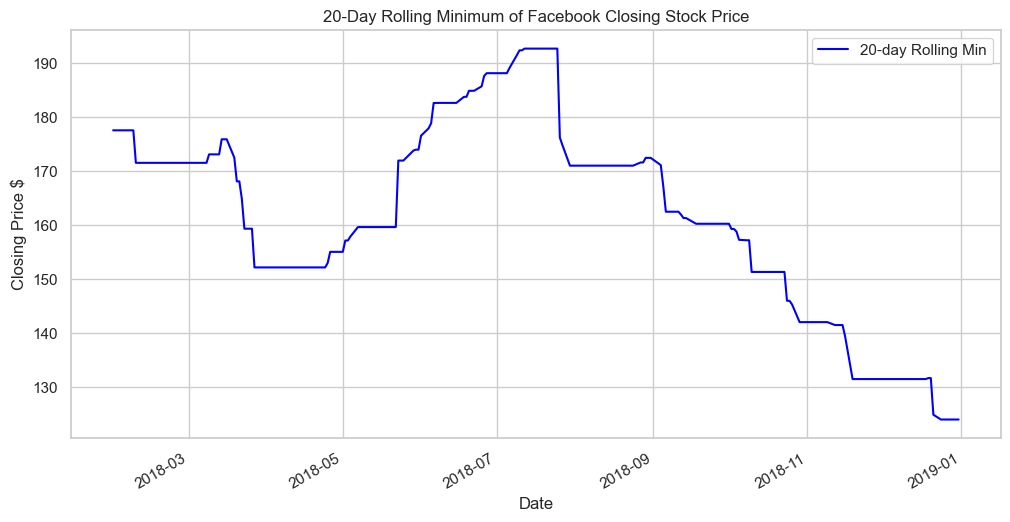

In [22]:
# Exercise 1 - rolling 20 day min of FB closing price with pandas
rolling_min = fb['close'].rolling(window=20).min()

plt.figure(figsize=(12,6))
rolling_min.plot(color='blue')

plt.title('20-Day Rolling Minimum of Facebook Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Closing Price $')
plt.legend(['20-day Rolling Min'])
plt.show()

# Exercise 2

Histogram and KDE of the change from open to close in fb stock price

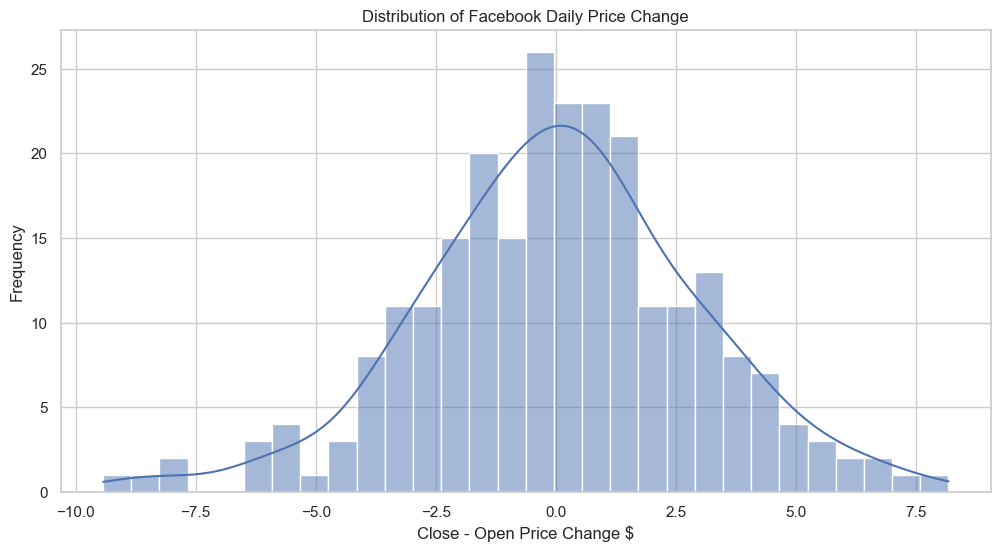

In [12]:
# Continue with your next problem
fb['daily_change'] = fb['close'] - fb['open']

plt.figure(figsize=(12,6))

sns.histplot(
    fb['daily_change'],
    kde=True,
    bins=30)

plt.title('Distribution of Facebook Daily Price Change')
plt.xlabel('Close - Open Price Change $')
plt.ylabel('Frequency')

plt.show()

# Exercise 3

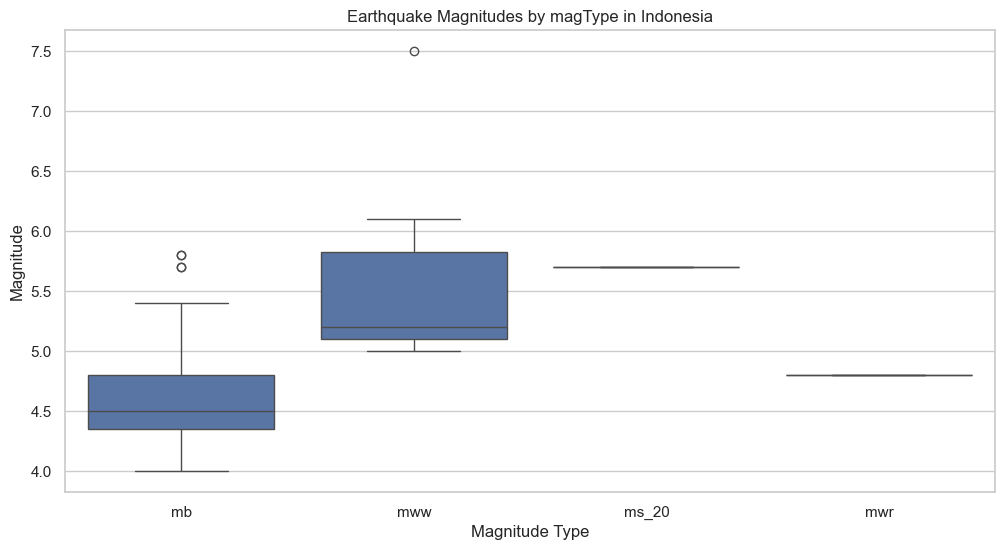

In [14]:
#Box plots for Earthquake magnitudes by magType in Indonesia
ind_quakes = quake[
    quake['parsed_place'].str.contains('Indonesia', na=False)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data = ind_quakes,
    x = 'magType',
    y='mag')


plt.title('Earthquake Magnitudes by magType in Indonesia')
plt.xlabel('Magnitude Type')
plt.ylabel('Magnitude')

plt.show()

# Exercise 4
### Line plot of weekly max high minus weekly low for fb stock


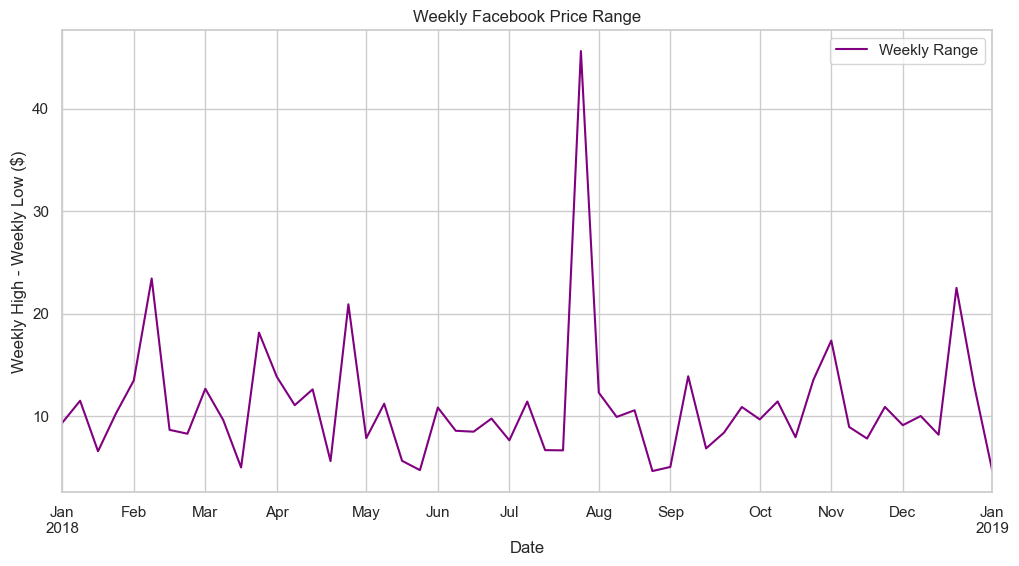

In [15]:
weekly_range = (fb['high'].resample('W').max() - 
                fb['low'].resample('W').min()
               )

plt.figure(figsize=(12,6))

weekly_range.plot(color='purple')

plt.title('Weekly Facebook Price Range')
plt.xlabel('Date')
plt.ylabel('Weekly High - Weekly Low ($)')
plt.legend(['Weekly Range'])

plt.show()

# Ch 6 Exercises

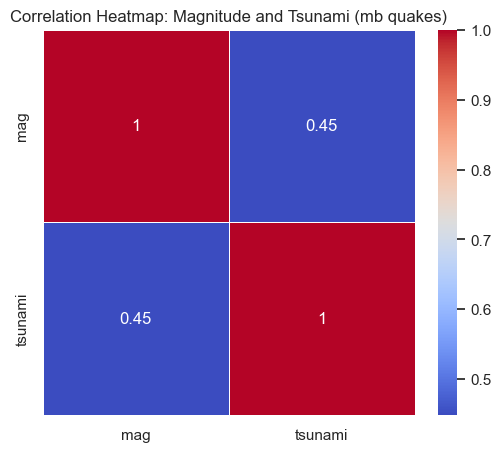

In [19]:
# Exercise 1 heatmap the correlation coefficients between earthquake magnitude and if there was a tsunami 
mb_quakes = quake1[quake1['magType'] == 'mb']

corr_data = mb_quakes[['mag', 'tsunami']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5)

plt.title('Correlation Heatmap: Magnitude and Tsunami (mb quakes)')
plt.show()

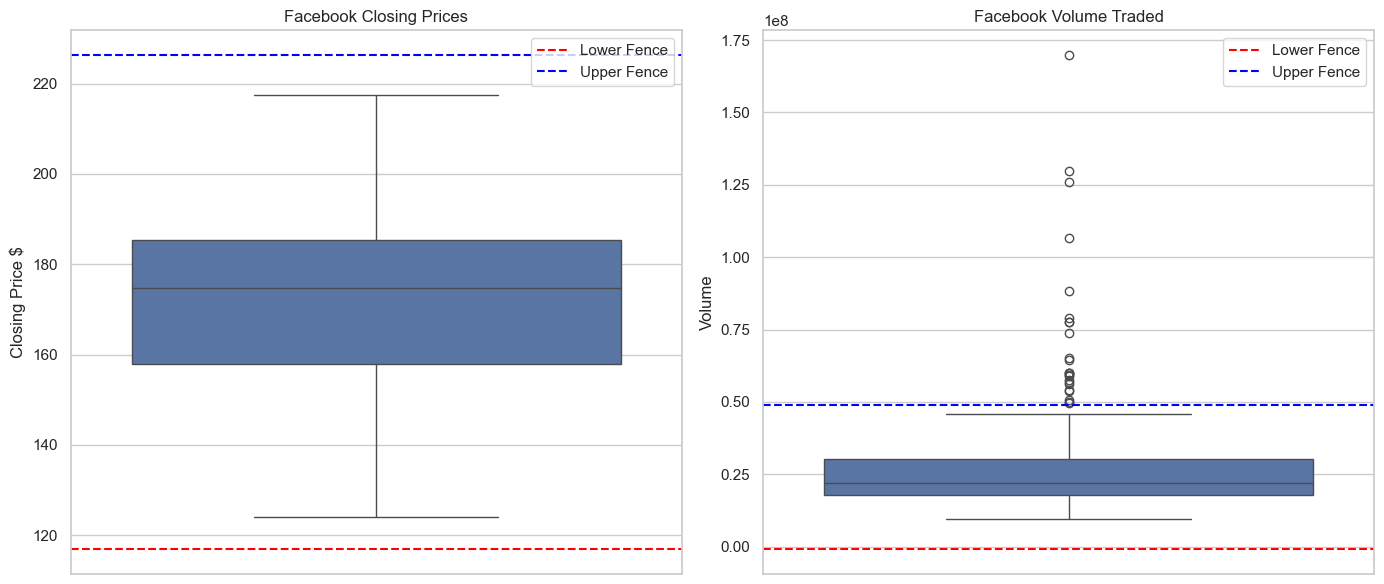

In [21]:
# exercise 2 - box plots of fb volume traded and closing prices with Tukey fence

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# closing price box plot 
close_q1 = fb1['close'].quantile(0.25)
close_q3 = fb1['close'].quantile(0.75)
close_iqr = close_q3 - close_q1

close_lower = close_q1 - 1.5 * close_iqr
close_upper = close_q3 + 1.5 * close_iqr


sns.boxplot(
    y=fb1['close'],
    ax=axes[0])

axes[0].axhline(close_lower, color = 'red', linestyle='--', label= 'Lower Fence')
axes[0].axhline(close_upper, color = 'blue', linestyle='--', label= 'Upper Fence')

axes[0].set_title('Facebook Closing Prices')
axes[0].set_ylabel('Closing Price $')
axes[0].legend()

# volume for traded box plot 
vol_q1 = fb1['volume'].quantile(0.25)
vol_q3 = fb1['volume'].quantile(0.75)

vol_iqr = vol_q3 - vol_q1

vol_lower =  vol_q1 - 1.5 * vol_iqr
vol_upper =  vol_q3 + 1.5 * vol_iqr

sns.boxplot(
    y=fb1['volume'],
    ax=axes[1])

axes[1].axhline(vol_lower, color = 'red', linestyle='--', label= 'Lower Fence')
axes[1].axhline(vol_upper, color = 'blue', linestyle='--', label= 'Upper Fence')

axes[1].set_title('Facebook Volume Traded')
axes[1].set_ylabel('Volume')
axes[1].legend()

plt.tight_layout()
plt.show()